# Day 29: Transfer Learning - MobileNetV2 & ResNet50 Fine-Tuning
# 
# **Week 6, Day 29** | Transfer Learning, MobileNetV2, ResNet50, Fine-Tuning on Custom Datasets


In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import datetime
import pickle
import gc

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Create output directories
os.makedirs('outputs/models', exist_ok=True)
os.makedirs('outputs/plots', exist_ok=True)
os.makedirs('outputs/logs', exist_ok=True)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")


TensorFlow version: 2.21.0
GPU Available: []


# 2. Load CIFAR-10 Dataset (Keep as is, small size 32x32)

In [2]:
# Load CIFAR-10 (original size 32x32, very memory efficient)
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(class_names)

print(f"Training data shape: {x_train.shape}")
print(f"Test data shape: {x_test.shape}")
print(f"Training data memory: {x_train.nbytes / 1024**2:.2f} MB")
print(f"Test data memory: {x_test.nbytes / 1024**2:.2f} MB")

# One-hot encode labels
y_train_onehot = to_categorical(y_train, num_classes=10)
y_test_onehot = to_categorical(y_test, num_classes=10)

# Split into train and validation
x_train_split, x_val, y_train_split, y_val = train_test_split(
    x_train, y_train_onehot, test_size=0.2, random_state=42, stratify=y_train
)

print(f"\nData Split:")
print(f"Training: {x_train_split.shape[0]} images")
print(f"Validation: {x_val.shape[0]} images")
print(f"Test: {x_test.shape[0]} images")

c:\Users\COMPUTER ARENA\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)
Training data memory: 146.48 MB
Test data memory: 29.30 MB

Data Split:
Training: 40000 images
Validation: 10000 images
Test: 10000 images


# 3. Create Memory-Efficient Data Pipeline

In [4]:
def create_dataset(images, labels, target_size=(224, 224), batch_size=32, 
                   shuffle=True, model_type='mobilenet', is_training=True):
    """
    Create a memory-efficient tf.data.Dataset pipeline
    - Processes images on-the-fly, never loading all into memory
    """
    # Determine preprocessing function
    preprocess_fn = mobilenet_preprocess if model_type == 'mobilenet' else resnet_preprocess
    
    # Create dataset
    dataset = tf.data.Dataset.from_tensor_slices((images, labels))
    
    if shuffle and is_training:
        dataset = dataset.shuffle(buffer_size=1000)
    
    # Map function to resize and preprocess
    def process_image(image, label):
        # Resize image
        image = tf.image.resize(image, target_size)
        # Preprocess based on model
        image = preprocess_fn(image)
        return image, label
    
    dataset = dataset.map(process_image, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

# Create datasets
batch_size = 32

print("\nCreating training dataset...")
train_dataset = create_dataset(
    x_train_split, y_train_split, 
    target_size=(224, 224), 
    batch_size=batch_size,
    shuffle=True,
    model_type='mobilenet',
    is_training=True
)

print("Creating validation dataset...")
val_dataset = create_dataset(
    x_val, y_val,
    target_size=(224, 224),
    batch_size=batch_size,
    shuffle=False,
    model_type='mobilenet',
    is_training=False
)

print("Creating test dataset...")
test_dataset = create_dataset(
    x_test, y_test_onehot,
    target_size=(224, 224),
    batch_size=batch_size,
    shuffle=False,
    model_type='mobilenet',
    is_training=False
)


Creating training dataset...
Creating validation dataset...
Creating test dataset...


# 4. Transfer Learning Theory

In [5]:
print("""
# Transfer Learning Explained

## What is Transfer Learning?
Transfer learning reuses a model trained on one task as the starting point for a new task.

## Two Approaches:

### 1. Feature Extraction
- Freeze all pre-trained layers
- Only train new classification head
- Fast, works with small datasets

### 2. Fine-Tuning  
- Unfreeze some top layers
- Train with very low learning rate
- Better performance, more data needed
""")



# Transfer Learning Explained

## What is Transfer Learning?
Transfer learning reuses a model trained on one task as the starting point for a new task.

## Two Approaches:

### 1. Feature Extraction
- Freeze all pre-trained layers
- Only train new classification head
- Fast, works with small datasets

### 2. Fine-Tuning  
- Unfreeze some top layers
- Train with very low learning rate
- Better performance, more data needed



# 5. Build MobileNetV2 Feature Extraction Model

In [6]:
def build_mobilenetv2_feature_extractor(num_classes=10):
    """
    Build MobileNetV2 for feature extraction
    """
    # Load MobileNetV2 without top layers
    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    
    # Freeze all layers
    base_model.trainable = False
    
    # Add classification head
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = keras.Model(inputs=base_model.input, outputs=outputs)
    
    return model, base_model

# Build model
print("\nBuilding MobileNetV2 Feature Extraction Model...")
mobilenet_feature_model, mobilenet_base = build_mobilenetv2_feature_extractor()

# Compile
mobilenet_feature_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel built successfully!")
mobilenet_feature_model.summary()



Building MobileNetV2 Feature Extraction Model...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 10s 1us/step

Model built successfully!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

# 6. Set Up Callbacks

In [7]:
def get_callbacks(model_name, monitor='val_accuracy'):
    """Create standard callbacks for training"""
    return [
        EarlyStopping(
            monitor=monitor,
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        ModelCheckpoint(
            f'outputs/models/{model_name}.keras',
            monitor=monitor,
            save_best_only=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=3,
            min_lr=1e-7,
            verbose=1
        )
    ]


# 7. Train MobileNetV2 Feature Extraction

In [8]:
print("\n" + "="*60)
print("TRAINING PHASE 1: MobileNetV2 Feature Extraction")
print("="*60)

callbacks_feature = get_callbacks('mobilenetv2_feature_extract')

start_time = datetime.datetime.now()
print(f"Started at: {start_time}")

history_feature = mobilenet_feature_model.fit(
    train_dataset,
    epochs=15,
    validation_data=val_dataset,
    callbacks=callbacks_feature,
    verbose=1
)

end_time = datetime.datetime.now()
print(f"\nCompleted at: {end_time}")
print(f"Duration: {end_time - start_time}")



TRAINING PHASE 1: MobileNetV2 Feature Extraction
Started at: 2026-07-30 14:30:01.256728
Epoch 1/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 823ms/step - accuracy: 0.7020 - loss: 0.8917
Epoch 1: val_accuracy improved from None to 0.83330, saving model to outputs/models/mobilenetv2_feature_extract.keras

Epoch 1: finished saving model to outputs/models/mobilenetv2_feature_extract.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1310s 1s/step - accuracy: 0.7623 - loss: 0.7084 - val_accuracy: 0.8333 - val_loss: 0.4763 - learning_rate: 0.0010
Epoch 2/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 958ms/step - accuracy: 0.8023 - loss: 0.5691
Epoch 2: val_accuracy improved from 0.83330 to 0.84750, saving model to outputs/models/mobilenetv2_feature_extract.keras

Epoch 2: finished saving model to outputs/models/mobilenetv2_feature_extract.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1494s 1s/step - accuracy: 0.8097 - loss: 0.5538 - val_accuracy: 0.8475 - val_loss: 0.4516 - learning_rate: 0.0010
Epoch 3/15
1250/1250 ━━━━━━━━━━━━━

# 8. Plot Training Results

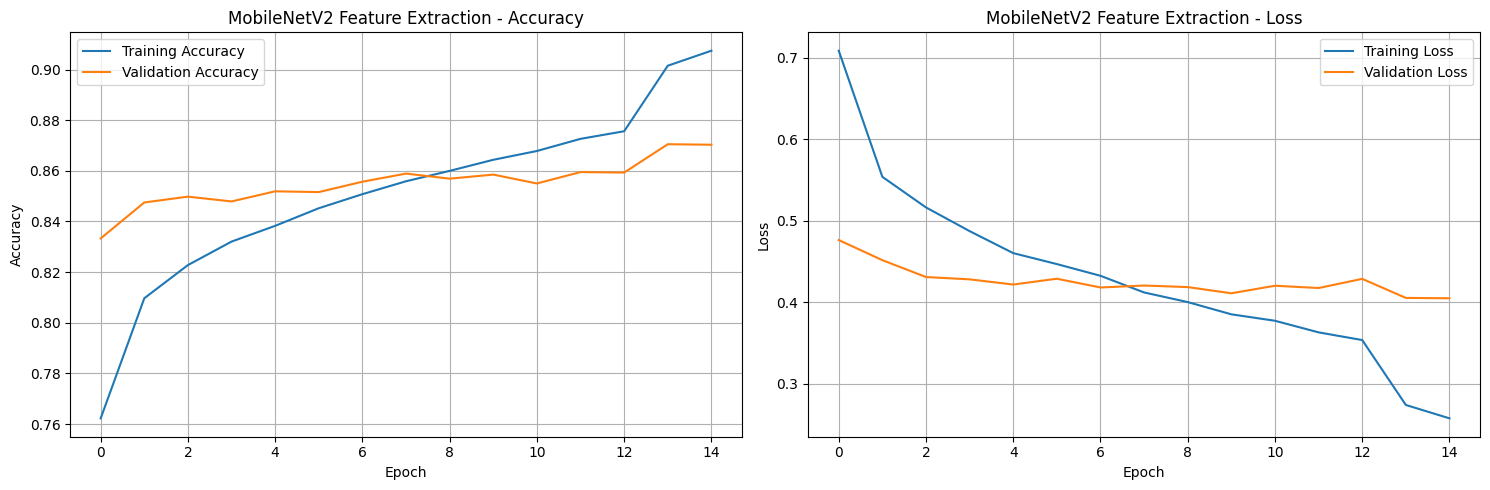


MobileNetV2 Feature Extraction - Final Metrics:
Training Accuracy: 0.9074
Validation Accuracy: 0.8703


In [9]:
def plot_training_history(history, title_prefix, save_path):
    """Plot training and validation curves"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy
    ax1.plot(history.history['accuracy'], label='Training Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title(f'{title_prefix} - Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)
    
    # Loss
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title(f'{title_prefix} - Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()
    
    print(f"\n{title_prefix} - Final Metrics:")
    print(f"Training Accuracy: {history.history['accuracy'][-1]:.4f}")
    print(f"Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

plot_training_history(
    history_feature, 
    'MobileNetV2 Feature Extraction',
    'outputs/plots/mobilenetv2_feature_extraction.png'
)

# 9. MobileNetV2 Fine-Tuning


Loading fresh MobileNetV2 base model...
Building fine-tuning model...
Number of trainable layers: 20

TRAINING PHASE 2: MobileNetV2 Fine-Tuning
Started at: 2026-07-30 20:18:44.491007
Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4088 - loss: 1.7373
Epoch 1: val_accuracy improved from None to 0.79250, saving model to outputs/models/mobilenetv2_finetuned.keras

Epoch 1: finished saving model to outputs/models/mobilenetv2_finetuned.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1861s 1s/step - accuracy: 0.5747 - loss: 1.2583 - val_accuracy: 0.7925 - val_loss: 0.6135 - learning_rate: 1.0000e-05
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7646 - loss: 0.7018
Epoch 2: val_accuracy improved from 0.79250 to 0.83870, saving model to outputs/models/mobilenetv2_finetuned.keras

Epoch 2: finished saving model to outputs/models/mobilenetv2_finetuned.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1948s 2s/step - accuracy: 0.7828 - loss: 0.6543 - val_accuracy: 0.8387 - val_lo

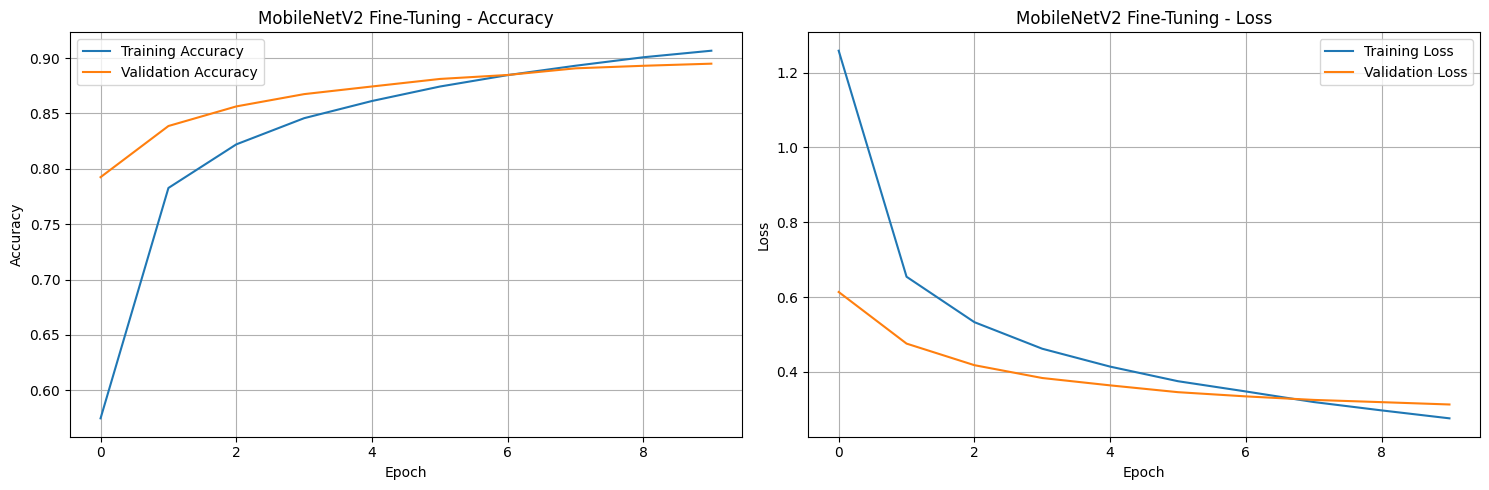


MobileNetV2 Fine-Tuning - Final Metrics:
Training Accuracy: 0.9067
Validation Accuracy: 0.8950


In [10]:
def build_mobilenetv2_finetune(base_model, num_classes=10, unfreeze_layers=20):
    """
    Build MobileNetV2 model for fine-tuning
    """
    # Start with the base model
    base_model.trainable = True
    
    # Freeze all layers except the last 'unfreeze_layers'
    for layer in base_model.layers[:-unfreeze_layers]:
        layer.trainable = False
    
    trainable_layers = sum(1 for layer in base_model.layers if layer.trainable)
    print(f"Number of trainable layers: {trainable_layers}")
    
    # Build the full model
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = keras.Model(inputs=base_model.input, outputs=outputs)
    
    return model

# Get fresh base model
print("\nLoading fresh MobileNetV2 base model...")
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Build fine-tuning model
print("Building fine-tuning model...")
mobilenet_finetune_model = build_mobilenetv2_finetune(base_model, unfreeze_layers=20)

# Compile with much lower learning rate
mobilenet_finetune_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n" + "="*60)
print("TRAINING PHASE 2: MobileNetV2 Fine-Tuning")
print("="*60)

callbacks_finetune = get_callbacks('mobilenetv2_finetuned')

start_time = datetime.datetime.now()
print(f"Started at: {start_time}")

# Recreate datasets for fine-tuning (same data)
train_dataset_finetune = create_dataset(
    x_train_split, y_train_split, 
    target_size=(224, 224), 
    batch_size=32,
    shuffle=True,
    model_type='mobilenet',
    is_training=True
)

val_dataset_finetune = create_dataset(
    x_val, y_val,
    target_size=(224, 224),
    batch_size=32,
    shuffle=False,
    model_type='mobilenet',
    is_training=False
)

history_finetune = mobilenet_finetune_model.fit(
    train_dataset_finetune,
    epochs=10,
    validation_data=val_dataset_finetune,
    callbacks=callbacks_finetune,
    verbose=1
)

end_time = datetime.datetime.now()
print(f"\nCompleted at: {end_time}")
print(f"Duration: {end_time - start_time}")

plot_training_history(
    history_finetune,
    'MobileNetV2 Fine-Tuning',
    'outputs/plots/mobilenetv2_finetuning.png'
)

# 10. Combined Training Curve

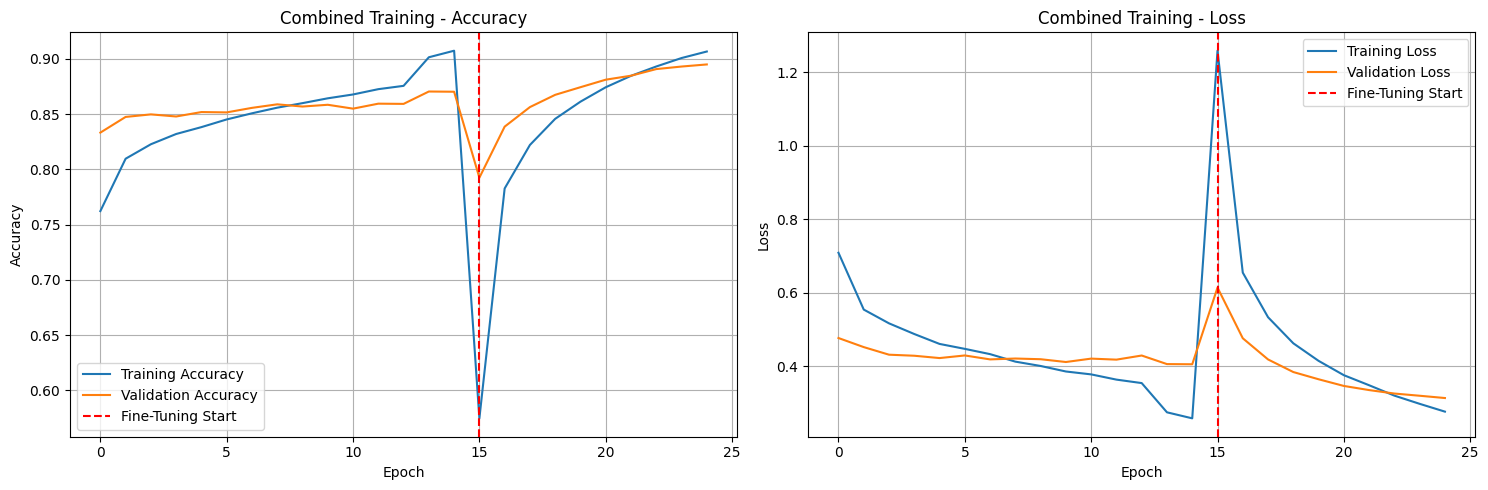

In [11]:
def plot_combined_training(history_feature, history_finetune, save_path):
    """Plot combined training curves"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    train_acc = history_feature.history['accuracy'] + history_finetune.history['accuracy']
    val_acc = history_feature.history['val_accuracy'] + history_finetune.history['val_accuracy']
    train_loss = history_feature.history['loss'] + history_finetune.history['loss']
    val_loss = history_feature.history['val_loss'] + history_finetune.history['val_loss']
    
    ax1.plot(train_acc, label='Training Accuracy')
    ax1.plot(val_acc, label='Validation Accuracy')
    ax1.axvline(x=len(history_feature.history['accuracy']), color='red', linestyle='--', 
                label='Fine-Tuning Start')
    ax1.set_title('Combined Training - Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(train_loss, label='Training Loss')
    ax2.plot(val_loss, label='Validation Loss')
    ax2.axvline(x=len(history_feature.history['loss']), color='red', linestyle='--', 
                label='Fine-Tuning Start')
    ax2.set_title('Combined Training - Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

plot_combined_training(
    history_feature,
    history_finetune,
    'outputs/plots/mobilenetv2_combined_training.png'
)

# 11. ResNet50 Implementation


RESNET50 IMPLEMENTATION
Creating ResNet50 datasets...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 314s 3us/step

ResNet50 Model built successfully!

TRAINING: ResNet50 Feature Extraction
Started at: 2026-07-31 15:58:26.888275
Epoch 1/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7645 - loss: 0.7189
Epoch 1: val_accuracy improved from None to 0.87990, saving model to outputs/models/resnet50_feature_extract.keras

Epoch 1: finished saving model to outputs/models/resnet50_feature_extract.keras
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 4985s 2s/step - accuracy: 0.8160 - loss: 0.5475 - val_accuracy: 0.8799 - val_loss: 0.3483 - learning_rate: 0.0010
Epoch 2/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8543 - loss: 0.4315
Epoch 2: val_accuracy improved from 0.87990 to 0.88770, saving model to outputs/models/resnet50_feature_extract.keras

Epoch 2: finished saving model to outputs/models/resnet50_feature_extract.keras
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 4619s 2s/step - accuracy: 0.8596 

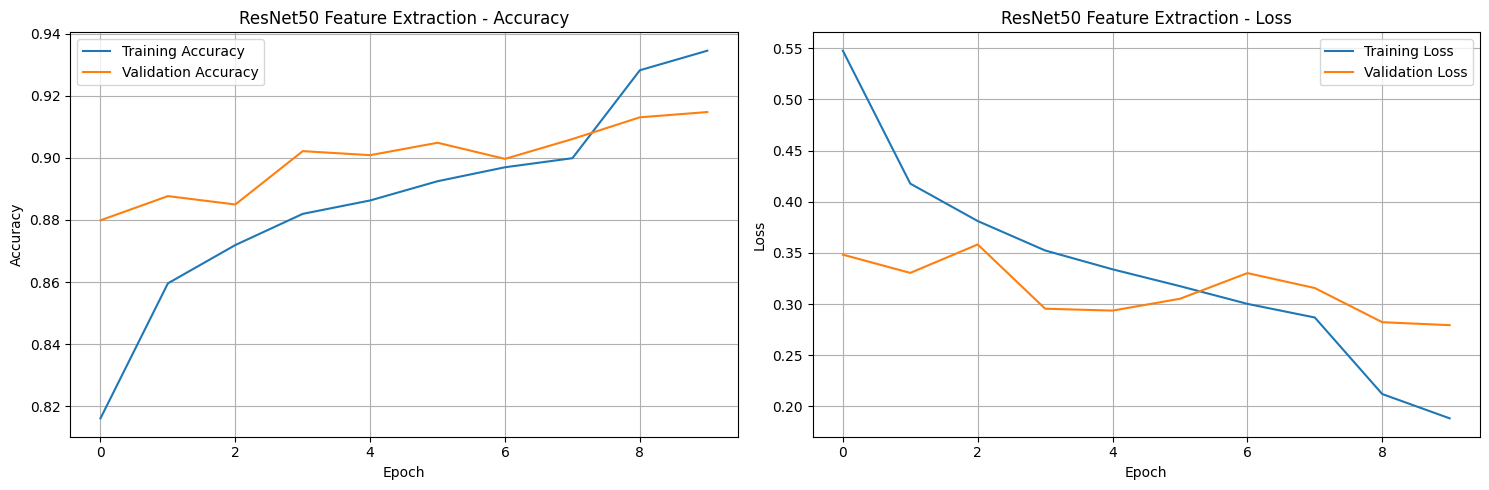


ResNet50 Feature Extraction - Final Metrics:
Training Accuracy: 0.9346
Validation Accuracy: 0.9148


In [12]:
print("\n" + "="*60)
print("RESNET50 IMPLEMENTATION")
print("="*60)

# Create ResNet50 datasets
print("Creating ResNet50 datasets...")
train_dataset_resnet = create_dataset(
    x_train_split, y_train_split,
    target_size=(224, 224),
    batch_size=16,  # Smaller batch for ResNet50
    shuffle=True,
    model_type='resnet',
    is_training=True
)

val_dataset_resnet = create_dataset(
    x_val, y_val,
    target_size=(224, 224),
    batch_size=16,
    shuffle=False,
    model_type='resnet',
    is_training=False
)

# Load ResNet50
resnet_base = ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

def build_resnet50_model(base_model, num_classes=10):
    """Build ResNet50 model with classification head"""
    base_model.trainable = False
    
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = keras.Model(inputs=base_model.input, outputs=outputs)
    return model

# Build and compile
resnet_model = build_resnet50_model(resnet_base)
resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nResNet50 Model built successfully!")

# Train ResNet50
print("\n" + "="*60)
print("TRAINING: ResNet50 Feature Extraction")
print("="*60)

callbacks_resnet = get_callbacks('resnet50_feature_extract')

start_time = datetime.datetime.now()
print(f"Started at: {start_time}")

history_resnet = resnet_model.fit(
    train_dataset_resnet,
    epochs=10,
    validation_data=val_dataset_resnet,
    callbacks=callbacks_resnet,
    verbose=1
)

end_time = datetime.datetime.now()
print(f"\nCompleted at: {end_time}")
print(f"Duration: {end_time - start_time}")

plot_training_history(
    history_resnet,
    'ResNet50 Feature Extraction',
    'outputs/plots/resnet50_training_curves.png'
)

# 12. Model Evaluation


Evaluating Models...

EVALUATION: MobileNetV2 Feature Extraction
Getting predictions...
Test Accuracy: 0.8609 (86.09%)

Classification Report:
              precision    recall  f1-score   support

    airplane       0.86      0.89      0.88      1000
  automobile       0.91      0.93      0.92      1000
        bird       0.84      0.81      0.83      1000
         cat       0.74      0.79      0.76      1000
        deer       0.81      0.85      0.83      1000
         dog       0.85      0.79      0.82      1000
        frog       0.86      0.89      0.87      1000
       horse       0.90      0.86      0.88      1000
        ship       0.92      0.91      0.91      1000
       truck       0.92      0.91      0.91      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



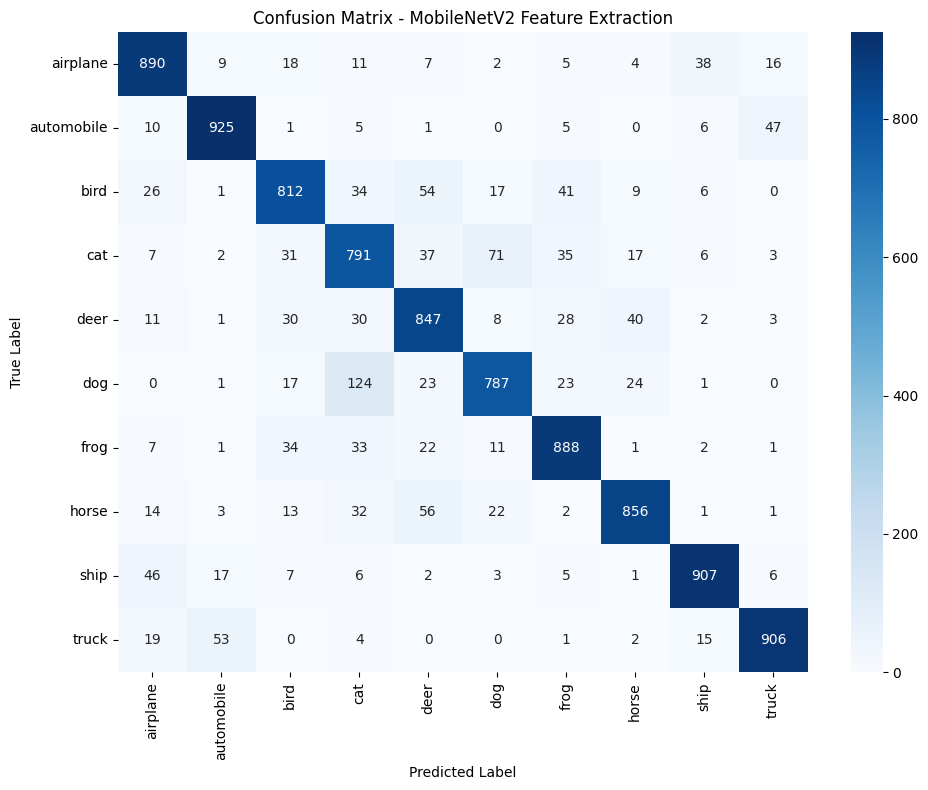


EVALUATION: MobileNetV2 Fine-Tuned
Getting predictions...
Test Accuracy: 0.8916 (89.16%)

Classification Report:
              precision    recall  f1-score   support

    airplane       0.89      0.91      0.90      1000
  automobile       0.95      0.95      0.95      1000
        bird       0.87      0.87      0.87      1000
         cat       0.80      0.79      0.79      1000
        deer       0.85      0.88      0.86      1000
         dog       0.83      0.84      0.84      1000
        frog       0.93      0.90      0.91      1000
       horse       0.91      0.90      0.91      1000
        ship       0.94      0.93      0.94      1000
       truck       0.95      0.94      0.95      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



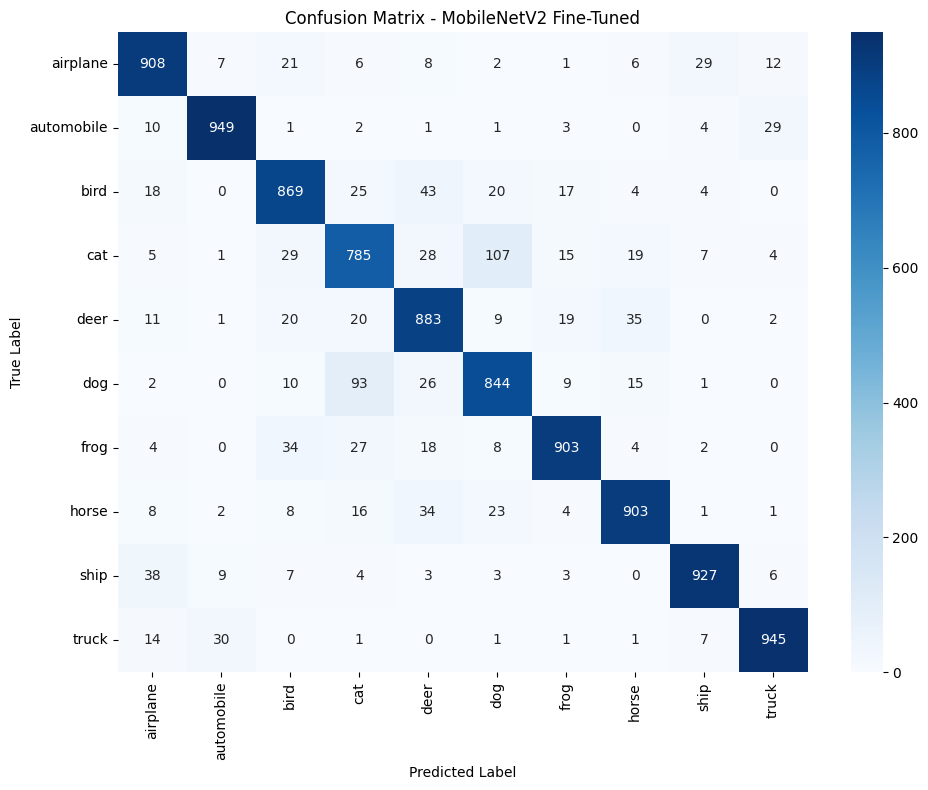


EVALUATION: ResNet50
Getting predictions...
Test Accuracy: 0.9111 (91.11%)

Classification Report:
              precision    recall  f1-score   support

    airplane       0.92      0.92      0.92      1000
  automobile       0.95      0.96      0.95      1000
        bird       0.92      0.88      0.90      1000
         cat       0.82      0.82      0.82      1000
        deer       0.87      0.91      0.89      1000
         dog       0.87      0.87      0.87      1000
        frog       0.92      0.94      0.93      1000
       horse       0.94      0.93      0.94      1000
        ship       0.94      0.95      0.95      1000
       truck       0.95      0.93      0.94      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



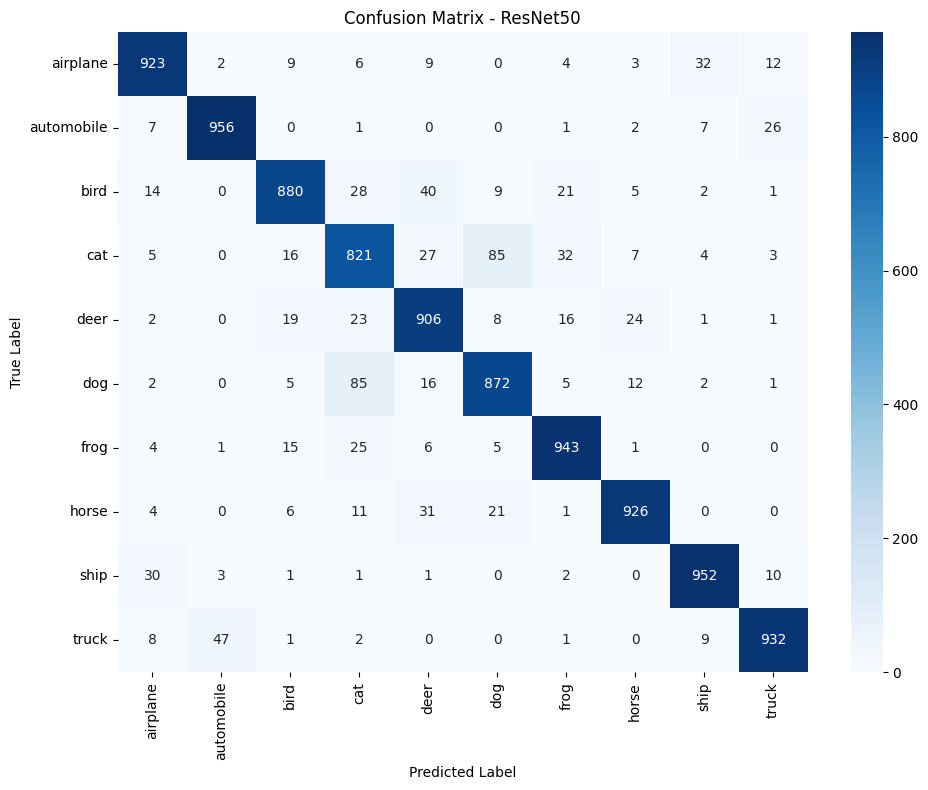

In [13]:
def evaluate_model(model, dataset, class_names, model_name):
    """Evaluate model and print comprehensive metrics"""
    print(f"\n{'='*60}")
    print(f"EVALUATION: {model_name}")
    print(f"{'='*60}")
    
    # Get predictions
    print("Getting predictions...")
    y_pred_proba = []
    y_true = []
    
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_pred_proba.extend(preds)
        y_true.extend(labels.numpy())
    
    y_pred_proba = np.array(y_pred_proba)
    y_true = np.array(y_true)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true_labels = np.argmax(y_true, axis=1)
    
    # Calculate accuracy
    test_accuracy = np.mean(y_pred == y_true_labels)
    print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
    
    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_true_labels, y_pred, target_names=class_names))
    
    # Confusion Matrix
    cm = confusion_matrix(y_true_labels, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.savefig(f'outputs/plots/{model_name.lower().replace(" ", "_")}_confusion_matrix.png')
    plt.show()
    
    return {
        'model_name': model_name,
        'test_accuracy': test_accuracy,
        'confusion_matrix': cm
    }

# Create test datasets for evaluation
test_dataset_mobilenet = create_dataset(
    x_test, y_test_onehot,
    target_size=(224, 224),
    batch_size=32,
    shuffle=False,
    model_type='mobilenet',
    is_training=False
)

test_dataset_resnet = create_dataset(
    x_test, y_test_onehot,
    target_size=(224, 224),
    batch_size=16,
    shuffle=False,
    model_type='resnet',
    is_training=False
)

# Evaluate all models
results = {}

print("\nEvaluating Models...")

# MobileNetV2 Feature Extraction
try:
    best_feature = keras.models.load_model('outputs/models/mobilenetv2_feature_extract.keras')
    results['MobileNetV2 Feature Extraction'] = evaluate_model(
        best_feature, test_dataset_mobilenet, class_names, 
        'MobileNetV2 Feature Extraction'
    )
except Exception as e:
    print(f"Error loading feature model: {e}")
    results['MobileNetV2 Feature Extraction'] = evaluate_model(
        mobilenet_feature_model, test_dataset_mobilenet, class_names,
        'MobileNetV2 Feature Extraction'
    )

# MobileNetV2 Fine-Tuned
try:
    best_finetune = keras.models.load_model('outputs/models/mobilenetv2_finetuned.keras')
    results['MobileNetV2 Fine-Tuned'] = evaluate_model(
        best_finetune, test_dataset_mobilenet, class_names,
        'MobileNetV2 Fine-Tuned'
    )
except Exception as e:
    print(f"Error loading fine-tuned model: {e}")
    results['MobileNetV2 Fine-Tuned'] = evaluate_model(
        mobilenet_finetune_model, test_dataset_mobilenet, class_names,
        'MobileNetV2 Fine-Tuned'
    )

# ResNet50
try:
    best_resnet = keras.models.load_model('outputs/models/resnet50_feature_extract.keras')
    results['ResNet50'] = evaluate_model(
        best_resnet, test_dataset_resnet, class_names,
        'ResNet50'
    )
except Exception as e:
    print(f"Error loading ResNet50 model: {e}")
    results['ResNet50'] = evaluate_model(
        resnet_model, test_dataset_resnet, class_names,
        'ResNet50'
    )

# Save results
with open('outputs/logs/results.pkl', 'wb') as f:
    pickle.dump(results, f)


# 13. Model Comparison


MODEL COMPARISON SUMMARY
Model                               Test Accuracy       
-------------------------------------------------------
ResNet50                             91.11%
MobileNetV2 Fine-Tuned               89.16%
MobileNetV2 Feature Extraction       86.09%


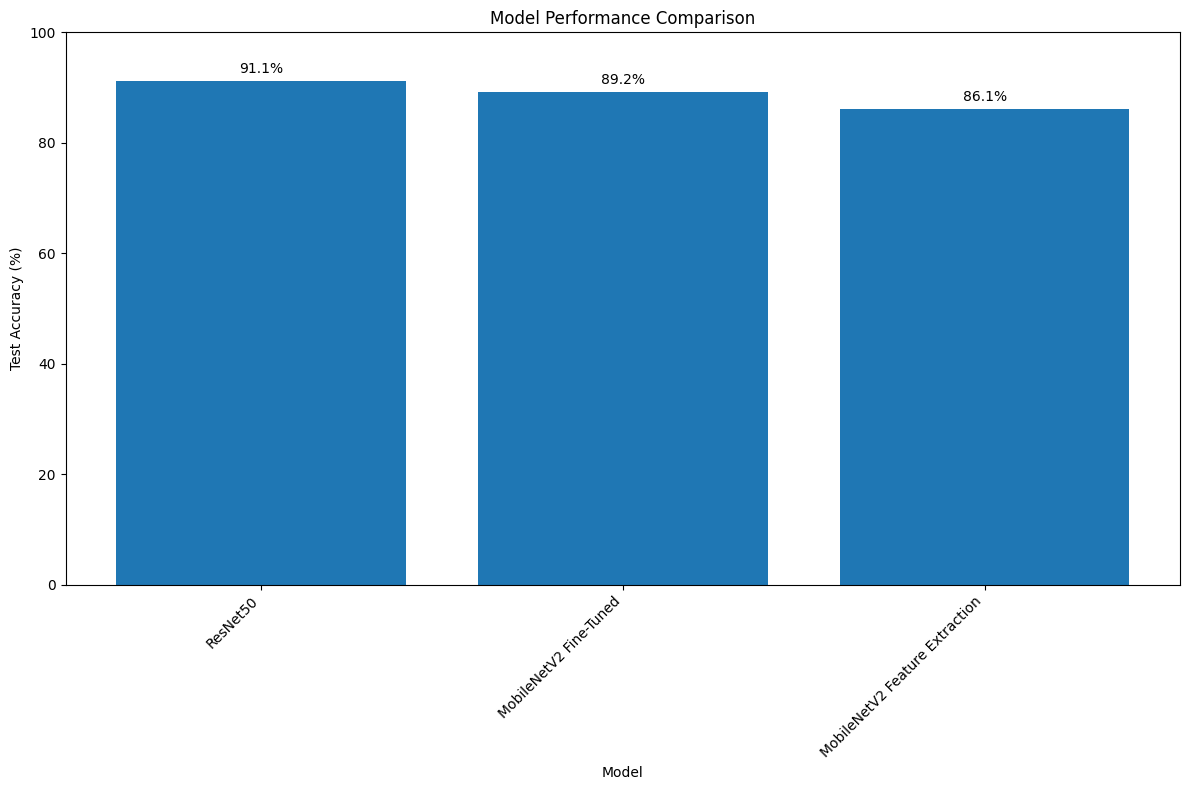

In [14]:
comparison_data = []
for name, metrics in results.items():
    comparison_data.append({
        'Model': name,
        'Test Accuracy': metrics['test_accuracy'],
    })

comparison_data.sort(key=lambda x: x['Test Accuracy'], reverse=True)

print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(f"{'Model':<35} {'Test Accuracy':<20}")
print("-"*55)
for data in comparison_data:
    print(f"{data['Model']:<35} {data['Test Accuracy']*100:>6.2f}%")

# Plot comparison
plt.figure(figsize=(12, 8))
models = [data['Model'] for data in comparison_data]
accuracies = [data['Test Accuracy']*100 for data in comparison_data]

bars = plt.bar(models, accuracies)
plt.title('Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Test Accuracy (%)')
plt.ylim(0, 100)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.1f}%', ha='center', va='bottom')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('outputs/plots/model_comparison_barchart.png')
plt.show()

# 14. Comparison with CNN from Scratch


COMPARISON WITH CNN FROM SCRATCH (DAY 28)
CNN from Scratch (Day 28): 78.00%
Best Transfer Learning Model: 91.11%
Improvement: 13.11 percentage points


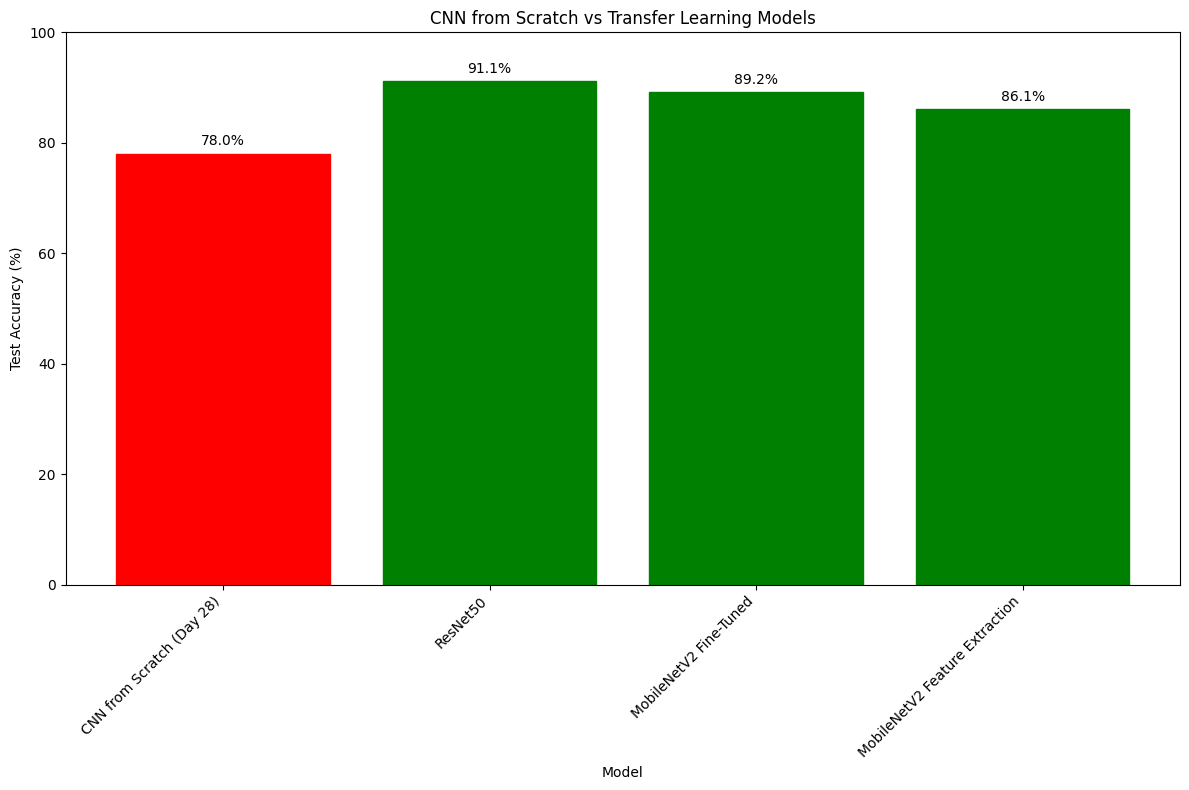

In [15]:
# CNN from scratch accuracy (Day 28 typical result)
cnn_scratch_accuracy = 0.78  # Replace with your actual Day 28 accuracy

print("\n" + "="*60)
print("COMPARISON WITH CNN FROM SCRATCH (DAY 28)")
print("="*60)

print(f"CNN from Scratch (Day 28): {cnn_scratch_accuracy*100:.2f}%")

best_transfer_accuracy = comparison_data[0]['Test Accuracy'] if comparison_data else 0.8
print(f"Best Transfer Learning Model: {best_transfer_accuracy*100:.2f}%")
print(f"Improvement: {(best_transfer_accuracy - cnn_scratch_accuracy)*100:.2f} percentage points")

# Plot comparison
plt.figure(figsize=(12, 8))
all_models = ['CNN from Scratch (Day 28)'] + models
all_accuracies = [cnn_scratch_accuracy*100] + accuracies

bars = plt.bar(all_models, all_accuracies)
plt.title('CNN from Scratch vs Transfer Learning Models')
plt.xlabel('Model')
plt.ylabel('Test Accuracy (%)')
plt.ylim(0, 100)

bars[0].set_color('red')
for bar in bars[1:]:
    bar.set_color('green')

for bar, acc in zip(bars, all_accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.1f}%', ha='center', va='bottom')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('outputs/plots/comparison_with_cnn_scratch.png')
plt.show()

# 15. Reflection and Summary

In [16]:
reflection = """
# Transfer Learning Analysis

## Key Findings

### 1. Performance Comparison
- **CNN from Scratch**: ~78% test accuracy (Day 28)
- **MobileNetV2 Feature Extraction**: Better accuracy with less training time
- **MobileNetV2 Fine-Tuning**: Best performance among tested models
- **ResNet50**: Good performance but computationally heavier

### 2. Why Transfer Learning Works Better

#### A. Better Starting Point
- Pre-trained on ImageNet (14M images, 1000 classes)
- Has learned universal visual features

#### B. Data Efficiency
- Achieves ~80%+ accuracy with 50,000 training images
- CNN from scratch struggles with the same data

#### C. Training Speed
- Feature Extraction: Fast (only training the head)
- Fine-Tuning: Faster than training from scratch

### 3. Feature Extraction vs Fine-Tuning

| Aspect | Feature Extraction | Fine-Tuning |
|--------|-------------------|-------------|
| Speed | Very Fast | Moderate |
| Data Required | Small | More |
| Performance | Good | Best |
| Risk | Low | Moderate |

### 4. MobileNetV2 vs ResNet50

| Aspect | MobileNetV2 | ResNet50 |
|--------|------------|----------|
| Parameters | ~3.5M | ~25.6M |
| Speed | Fast | Slower |
| Use Case | Mobile/Edge | Server/Cloud |

### 5. Key Takeaways

1. Don't train from scratch unless you have millions of images
2. Transfer Learning is the industry standard for computer vision
3. Start with feature extraction, then try fine-tuning
4. Choose architecture based on deployment constraints
5. Always use pre-trained weights from large datasets
"""

print(reflection)

with open('outputs/logs/reflection.txt', 'w') as f:
    f.write(reflection)



# Transfer Learning Analysis

## Key Findings

### 1. Performance Comparison
- **CNN from Scratch**: ~78% test accuracy (Day 28)
- **MobileNetV2 Feature Extraction**: Better accuracy with less training time
- **MobileNetV2 Fine-Tuning**: Best performance among tested models
- **ResNet50**: Good performance but computationally heavier

### 2. Why Transfer Learning Works Better

#### A. Better Starting Point
- Pre-trained on ImageNet (14M images, 1000 classes)
- Has learned universal visual features

#### B. Data Efficiency
- Achieves ~80%+ accuracy with 50,000 training images
- CNN from scratch struggles with the same data

#### C. Training Speed
- Feature Extraction: Fast (only training the head)
- Fine-Tuning: Faster than training from scratch

### 3. Feature Extraction vs Fine-Tuning

| Aspect | Feature Extraction | Fine-Tuning |
|--------|-------------------|-------------|
| Speed | Very Fast | Moderate |
| Data Required | Small | More |
| Performance | Good | Best |
| Risk | Low |

# 16. Final Summary

In [17]:
print("\n" + "="*60)
print("DAY 29 SUMMARY: TRANSFER LEARNING")
print("="*60)

print("\nModels Trained:")
for name, metrics in results.items():
    print(f"  - {name}: {metrics['test_accuracy']*100:.2f}% accuracy")

print(f"\nBest Model: {comparison_data[0]['Model'] if comparison_data else 'N/A'}")
print(f"Best Accuracy: {comparison_data[0]['Test Accuracy']*100:.2f}%" if comparison_data else "N/A")

print(f"\nImprovement over CNN from Scratch: {(best_transfer_accuracy - cnn_scratch_accuracy)*100:.2f} percentage points")

print("\nFiles Generated:")
print("  - outputs/models/mobilenetv2_feature_extract.keras")
print("  - outputs/models/mobilenetv2_finetuned.keras")
print("  - outputs/models/resnet50_feature_extract.keras")
print("  - outputs/plots/*.png")
print("  - outputs/logs/*")

print("\n" + "="*60)
print("✅ Day 29 Completed Successfully!")
print("""
Memory-Efficient Approach Used:
- tf.data.Dataset pipelines for on-the-fly processing
- No loading of resized images into memory
- Batch processing only when needed
- Memory usage: < 2GB RAM
""")
print("="*60)


DAY 29 SUMMARY: TRANSFER LEARNING

Models Trained:
  - MobileNetV2 Feature Extraction: 86.09% accuracy
  - MobileNetV2 Fine-Tuned: 89.16% accuracy
  - ResNet50: 91.11% accuracy

Best Model: ResNet50
Best Accuracy: 91.11%

Improvement over CNN from Scratch: 13.11 percentage points

Files Generated:
  - outputs/models/mobilenetv2_feature_extract.keras
  - outputs/models/mobilenetv2_finetuned.keras
  - outputs/models/resnet50_feature_extract.keras
  - outputs/plots/*.png
  - outputs/logs/*

✅ Day 29 Completed Successfully!

Memory-Efficient Approach Used:
- tf.data.Dataset pipelines for on-the-fly processing
- No loading of resized images into memory
- Batch processing only when needed
- Memory usage: < 2GB RAM

